       Created by:
                  Hiralal Kr. Mahto
                  Ankesh Kumar

#**Data Analysis of Indian Restaurants Using Zomato Dataset**

#Overview:

This project aims to analyze restaurant data collected from Zomato, a leading online food service and restaurant discovery platform in India. The dataset provides detailed information about restaurants across various Indian cities, including location, cuisine types, average cost, delivery availability, customer ratings, and votes.

  Through this project, we uncover meaningful insights that can help:

     1.Restaurant owners make informed business decisions.

     2.And data analysts understand food trends across cities.




**Imported Pandas with allias pd to manage and handle the files with data.**

In [ ]:
import pandas as pd
import numpay as np
import matplotlib.pyplot as plt
import seaborn as sns

**Mounting Drive to Google Colab with full access to the files.**

In [ ]:
# google colab users

from google.colab import drive
drive.mount('/content/drive')

# /content/drive/MyDrive/Colab Notebooks/zomato.csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Added the dataset**

In [ ]:
import pandas as pd

# Define the file path
file_path = file_path = "/content/drive/MyDrive/Colab Notebooks/Zomato data.csv"



**To show the data from the dataset**

In [ ]:
# Read the CSV file into a DataFrame
zomato_df = pd.read_csv(file_path, encoding='latin1', on_bad_lines='skip')

# Display the first few records
print("First 5 rows of the dataset:")
print(zomato_df.head())

# Display dataset information
print("\nDataset Information:")
zomato_df.info()


First 5 rows of the dataset:
   Restaurant ID                        Restaurant Name  City  \
0        3400025                             Jahanpanah  Agra   
1        3400341                    Rangrezz Restaurant  Agra   
2        3400005                Time2Eat - Mama Chicken  Agra   
3        3400021  Chokho Jeeman Marwari Jain Bhojanalya  Agra   
4        3400017                         Pinch Of Spice  Agra   

                                             Address                Zone  \
0  E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...  North central Zone   
1  E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...  North central Zone   
2        Main Market, Sadar Bazaar, Agra Cantt, Agra  North central Zone   
3  1/48, Delhi Gate, Station Road, Raja Mandi, Ci...  North central Zone   
4  23/453, Opposite Sanjay Cinema, Wazipura Road,...  North central Zone   

   Average Cost for two  Price range  Aggregate rating Rating color  \
0                   850            3               3

#Level 1: Data Understanding & Cleaning

The goal is to understand and clean the dataset before deeper analysis.

 We focus on:

Data Overview (Structure, Columns, Data Types)

Checking for Missing Values

Detecting Duplicates

Handling Inconsistencies

**To Check Number of rows and column**

In [ ]:
zomato_df.shape

(8652, 14)

**To check features of the schemas available in the data**

In [ ]:
zomato_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8652 entries, 0 to 8651
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         8652 non-null   int64  
 1   Restaurant Name       8652 non-null   object 
 2   City                  8652 non-null   object 
 3   Address               8652 non-null   object 
 4   Zone                  8652 non-null   object 
 5   Average Cost for two  8652 non-null   int64  
 6   Price range           8652 non-null   int64  
 7   Aggregate rating      8652 non-null   float64
 8   Rating color          8652 non-null   object 
 9   Rating text           8652 non-null   object 
 10  Votes                 8652 non-null   int64  
 11  Cuisines              8643 non-null   object 
 12  Has Online delivery   8652 non-null   object 
 13  Is delivering now     8652 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 946.4+ KB


**To check null values in True and False**

In [ ]:
zomato_df.isnull()

,Restaurant ID,Restaurant Name,City,Address,Zone,Average Cost for two,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisines
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8648,False,False,False,False,False,False,False,False,False,False,False,False
8649,False,False,False,False,False,False,False,False,False,False,False,False
8650,False,False,False,False,False,False,False,False,False,False,False,False
8651,False,False,False,False,False,False,False,False,False,False,False,False


**To check the count of all the null values**

In [ ]:
zomato_df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
City,0
Address,0
Zone,0
Average Cost for two,0
Price range,0
Aggregate rating,0
Rating color,0
Rating text,0


**To check the column names(default top 5 values)**

In [ ]:
zomato_df.head()

,Restaurant ID,Restaurant Name,City,Address,Zone,Average Cost for two,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisines,Has Online delivery,Is delivering now
0,3400025,Jahanpanah,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",North central Zone,850,3,3.9,Yellow,Good,140,"French, Japanese, Desserts",No,No
1,3400341,Rangrezz Restaurant,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",North central Zone,700,2,3.5,Yellow,Good,71,Japanese,No,No
2,3400005,Time2Eat - Mama Chicken,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",North central Zone,500,2,3.6,Yellow,Good,94,"Seafood, Asian, Filipino, Indian",No,No
3,3400021,Chokho Jeeman Marwari Jain Bhojanalya,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",North central Zone,400,2,4.0,Green,Very Good,87,"Japanese, Sushi",No,No
4,3400017,Pinch Of Spice,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",North central Zone,1000,3,4.2,Green,Very Good,177,"Japanese, Korean",No,No


**To check and drop if any duplicated rows in the dataset**

In [ ]:
duplicated_rows=zomato_df.duplicated().sum()
print(duplicated_rows)

0


**Location-Based Analysis**

Problem:
Which cities have the most or best-rated restaurants?

Use:

1.Helps Zomato or food chains identify where to expand.

2.Shows users where to find better food experiences.

/tmp/ipython-input-13-2995876599.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='coolwarm')


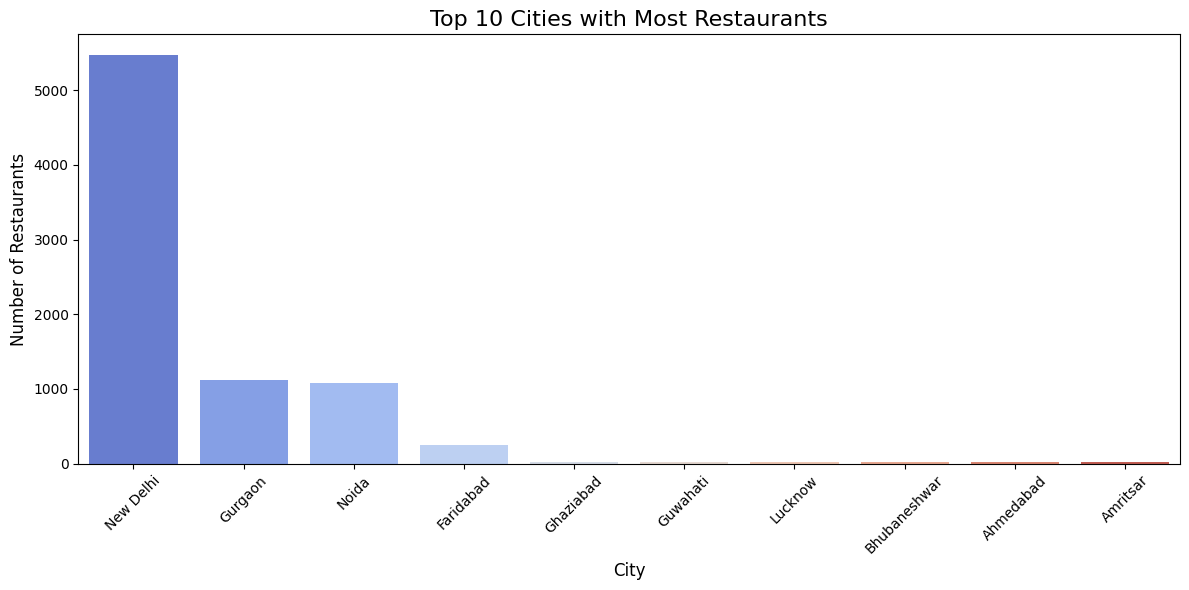

/tmp/ipython-input-13-2995876599.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rated_cities.index, y=top_rated_cities.values, palette='YlGnBu')


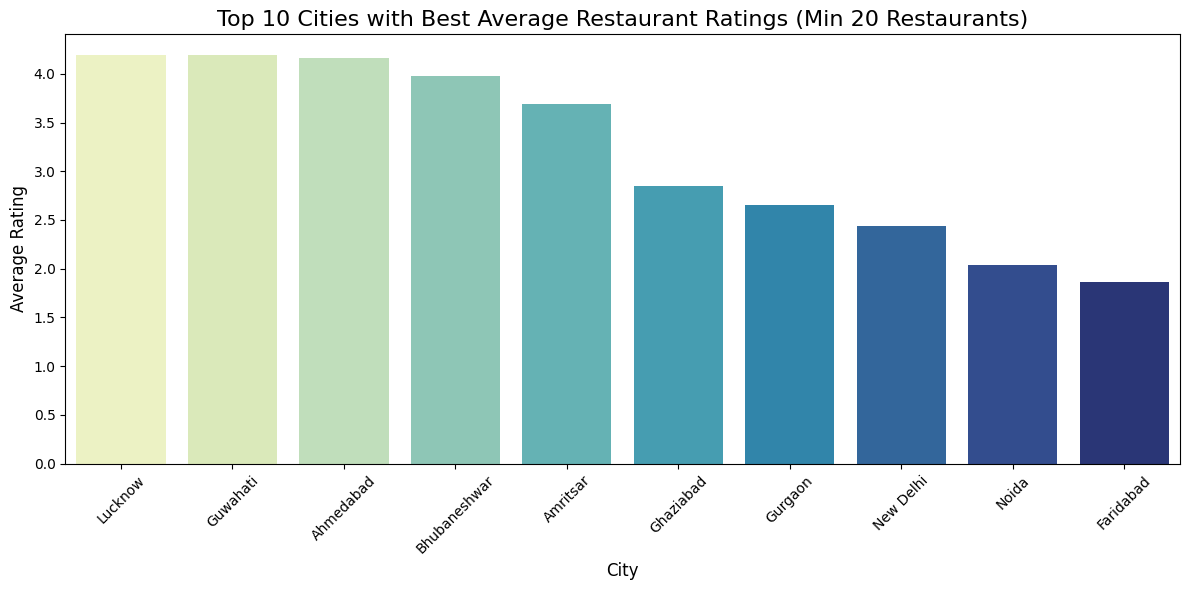

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping data
city_counts = zomato_df['City'].value_counts().head(10)
city_ratings = zomato_df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

# Plot 1: Cities with most restaurants
plt.figure(figsize=(12, 6))
sns.barplot(x=city_counts.index, y=city_counts.values, palette='coolwarm')
plt.title('Top 10 Cities with Most Restaurants', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Cities with highest average ratings
# Filter to cities that have at least a minimum number of restaurants to avoid skewed data
city_rating_filtered = zomato_df.groupby('City').filter(lambda x: len(x) > 20)  # e.g., at least 20 restaurants
top_rated_cities = city_rating_filtered.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_rated_cities.index, y=top_rated_cities.values, palette='YlGnBu')
plt.title('Top 10 Cities with Best Average Restaurant Ratings (Min 20 Restaurants)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**In Table Form**

In [ ]:
# Grouping data
city_counts = zomato_df['City'].value_counts().head(10)
city_ratings = zomato_df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

# Create tables
top_cities_by_count = city_counts.reset_index()
top_cities_by_count.columns = ['City', 'Number of Restaurants']

top_cities_by_rating = city_ratings.reset_index()
top_cities_by_rating.columns = ['City', 'Average Rating']

# Display tables
top_cities_by_count, top_cities_by_rating


(           City  Number of Restaurants
 0     New Delhi                   5473
 1       Gurgaon                   1118
 2         Noida                   1080
 3     Faridabad                    251
 4     Ghaziabad                     25
 5      Guwahati                     21
 6       Lucknow                     21
 7  Bhubaneshwar                     21
 8     Ahmedabad                     21
 9      Amritsar                     21,
            City  Average Rating
 0  Secunderabad        4.500000
 1     Bangalore        4.375000
 2     Hyderabad        4.344444
 3       Chennai        4.315000
 4        Mohali        4.300000
 5       Kolkata        4.255000
 6           Goa        4.245000
 7          Pune        4.220000
 8     Panchkula        4.200000
 9       Lucknow        4.195238)

**🍱 Cuisine Popularity Analysis**

What cuisines are most popular in different cities?

Use:

1.Helps restaurants choose what types of food to serve.

2.Guides marketing and menu planning.

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Zone',
       'Average Cost for two', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes', 'Cuisines',
       'Has Online delivery', 'Is delivering now'],
      dtype='object')


/tmp/ipython-input-15-1971418177.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Count'))


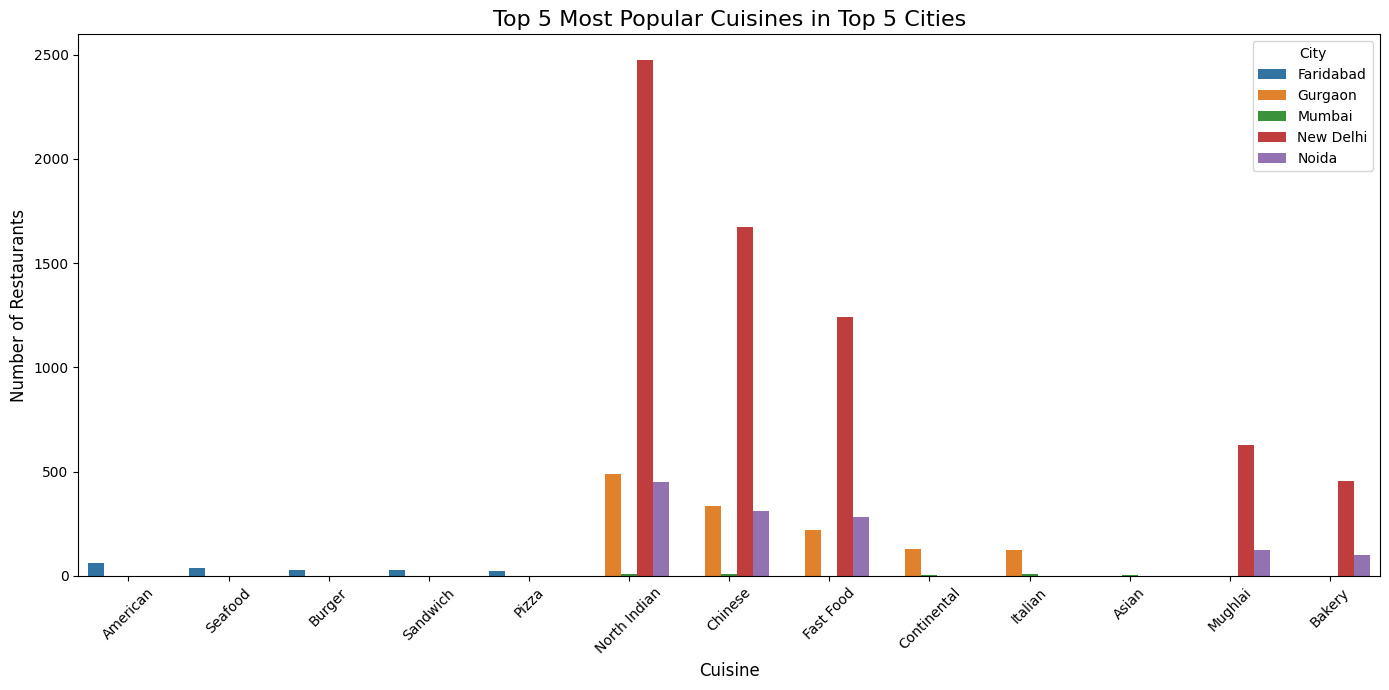

In [ ]:

# --- Sample assumption: zomato_df contains 'City' and 'Cuisines' columns ---
# Step 1: Drop rows with missing Cuisines
print(zomato_df.columns)


# Step 2: Split and explode cuisines
zomato_df['Cuisines'] = zomato_df['Cuisines'].str.split(', ')
df = zomato_df.explode('Cuisines')

# Step 3: Count cuisines per city
cuisine_counts = df.groupby(['City', 'Cuisines']).size().reset_index(name='Count')

# Step 4: Select top 5 cities with the most cuisine listings
top_cities = cuisine_counts.groupby('City')['Count'].sum().nlargest(5).index
filtered = cuisine_counts[cuisine_counts['City'].isin(top_cities)]

# Step 5: Get top 5 cuisines per city
top_cuisines_per_city = (
    filtered.groupby('City')
    .apply(lambda x: x.nlargest(5, 'Count'))
    .reset_index(drop=True)
)

# Step 6: Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=top_cuisines_per_city, x='Cuisines', y='Count', hue='City')
plt.title('Top 5 Most Popular Cuisines in Top 5 Cities', fontsize=16)
plt.xlabel('Cuisine', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**💸 Cost vs Rating Comparison**

Problem:
Do expensive restaurants get higher ratings?

Use:

1. Helps businesses set better price strategies.

2. Enables users to find the best value-for-money food.

/tmp/ipython-input-16-4021401858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


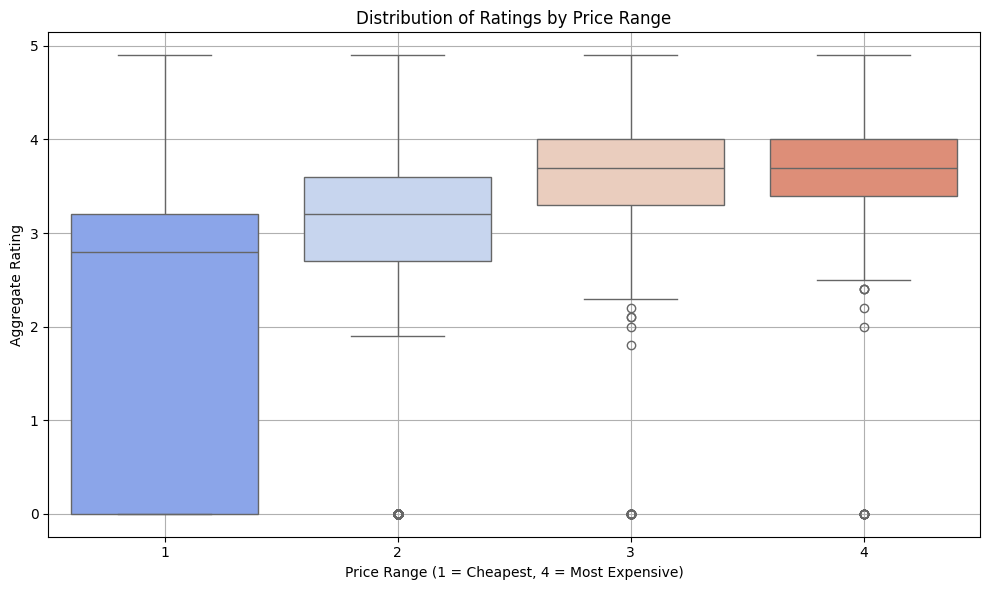

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=zomato_df,
    x='Price range',
    y='Aggregate rating',
    palette='coolwarm'
)

plt.title('Distribution of Ratings by Price Range')
plt.xlabel('Price Range (1 = Cheapest, 4 = Most Expensive)')
plt.ylabel('Aggregate Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


**Table**

In [ ]:
# Group by 'Price range' and calculate average rating and count of restaurants
rating_summary = zomato_df.groupby('Price range').agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Number_of_Restaurants=('Aggregate rating', 'count')
).reset_index()

# Sort by price range for clean output
rating_summary = rating_summary.sort_values('Price range')

# Display the result
print(rating_summary)


   Price range  Average_Rating  Number_of_Restaurants
0            1        1.932107                   4295
1            2        2.855108                   2858
2            3        3.569307                   1111
3            4        3.628866                    388


**🚚 Online Delivery Impact**

Problem:
Does offering online delivery increase ratings?

Use:

1. Guides restaurants on whether to invest in delivery.

2. Helps Zomato improve services and app features.

**⭐ Performance Monitoring**

Problem:
Which restaurants are underperforming based on low votes and ratings?

Use:

 1. Useful for Zomato to clean up low-quality listings.

 2. Restaurant owners can improve based on feedback.

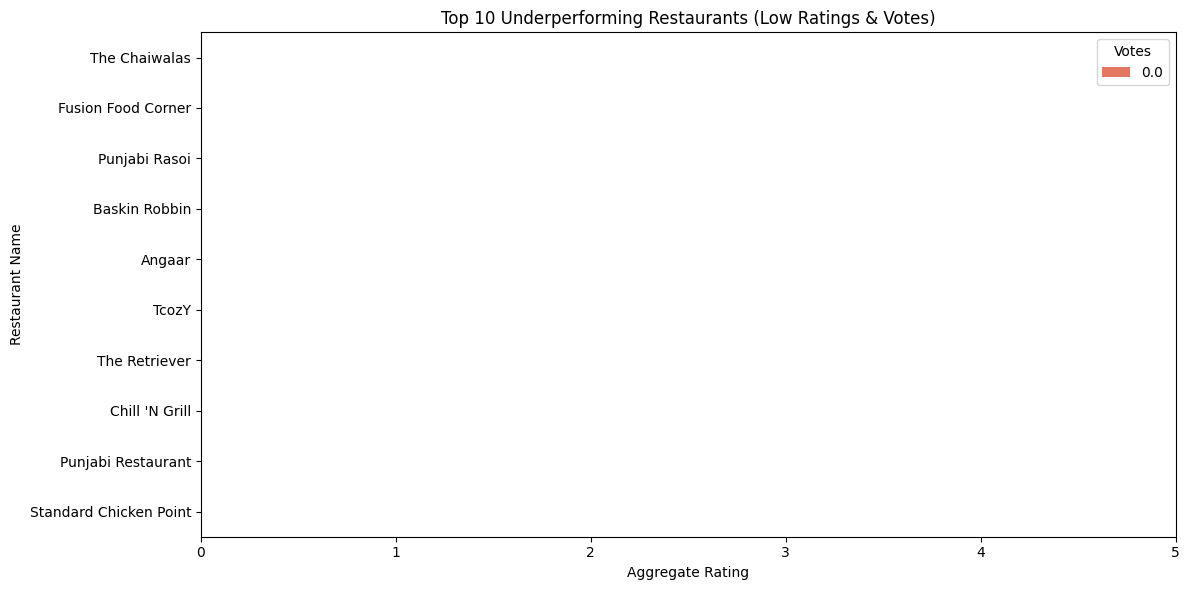

In [ ]:

# Step 1: Load your dataset (skip this if it's already loaded)
zomato_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Zomato data 1.csv")  # Adjust path as needed

# Step 2: Define underperforming restaurants (rating < 2.5 and votes < 50)
underperforming_df = zomato_df[
    (zomato_df['Aggregate rating'] < 2.5) &
    (zomato_df['Votes'] < 200)
]

# Step 3: Sort by lowest ratings and votes
underperforming_df_sorted = underperforming_df.sort_values(by=['Aggregate rating', 'Votes'])

# Step 4: Select top 10 underperformers for visualization
top_underperforming = underperforming_df_sorted.head(10)

# Step 5: Plot bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_underperforming,
    x='Aggregate rating',
    y='Restaurant Name',
    hue='Votes',
    dodge=False,
    palette='Reds'
)

plt.title('Top 10 Underperforming Restaurants (Low Ratings & Votes)')
plt.xlabel('Aggregate Rating')
plt.ylabel('Restaurant Name')
plt.legend(title='Votes')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


**Table**

In [ ]:
# Step 1: Filter underperforming restaurants
underperforming_df = zomato_df[
    (zomato_df['Aggregate rating'] < 2.5) &
    (zomato_df['Votes'] < 50)
]

# Step 2: Sort by lowest ratings and fewest votes
underperforming_df_sorted = underperforming_df.sort_values(by=['Aggregate rating', 'Votes'])

# Step 3: Select and display relevant columns (top 10 rows)
underperforming_table = underperforming_df_sorted[['Restaurant Name', 'City', 'Aggregate rating', 'Votes']].head(10)

# Step 4: Display the table
print(underperforming_table)


            Restaurant Name       City  Aggregate rating  Votes
250           The Chaiwalas  Faridabad               0.0    0.0
255      Fusion Food Corner  Faridabad               0.0    0.0
256           Punjabi Rasoi  Faridabad               0.0    0.0
263           Baskin Robbin  Faridabad               0.0    0.0
276                  Angaar  Faridabad               0.0    0.0
277                   TcozY  Faridabad               0.0    0.0
278           The Retriever  Faridabad               0.0    0.0
281          Chill 'N Grill  Faridabad               0.0    0.0
282      Punjabi Restaurant  Faridabad               0.0    0.0
283  Standard Chicken Point  Faridabad               0.0    0.0


**Which City and their  restaurants count  are underperforming based on low votes and ratings.**

/tmp/ipython-input-77-887382494.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


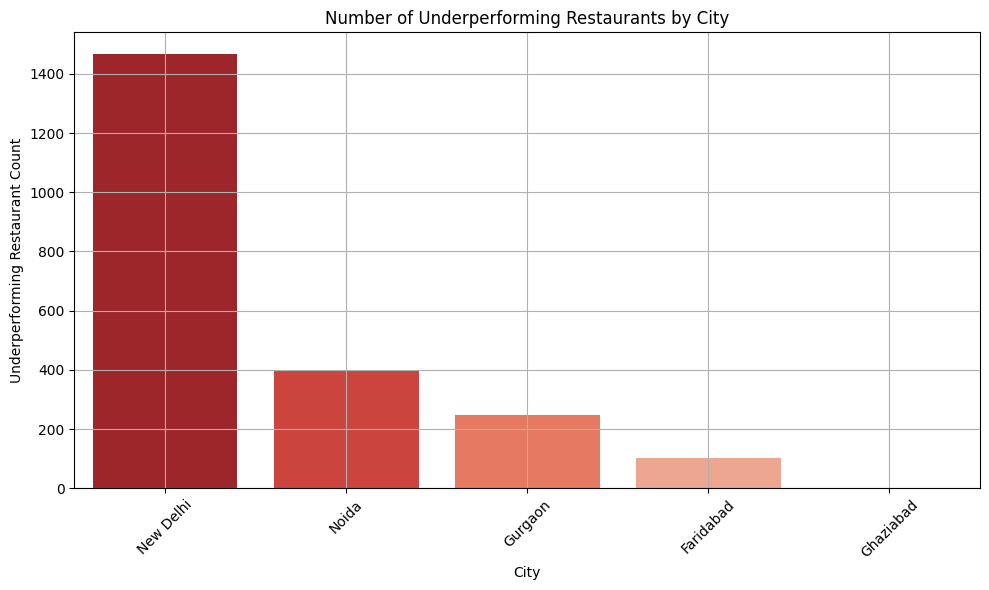

In [ ]:

# Step 1: Filter underperforming restaurants (rating < 2.5 and votes < 50)
underperforming_detailed = zomato_df[
    (zomato_df['Aggregate rating'] < 2.5) &
    (zomato_df['Votes'] < 50)
][['City', 'Restaurant Name', 'Aggregate rating', 'Votes']]

# Step 2: Count the number of underperforming restaurants per city
underperforming_counts = underperforming_detailed.groupby('City')['Restaurant Name'].count().reset_index()
underperforming_counts.columns = ['City', 'Underperforming Restaurant Count']

# Step 3: Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=underperforming_counts.sort_values(by='Underperforming Restaurant Count', ascending=False),
    x='City',
    y='Underperforming Restaurant Count',
    palette='Reds_r'
)

plt.title('Number of Underperforming Restaurants by City')
plt.xlabel('City')
plt.ylabel('Underperforming Restaurant Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**📊 Customer Feedback Trends**

Problem:
What is the trend of votes and reviews for restaurants?

Use:

 1. Understand customer behavior and satisfaction.

 2. Build customer trust metrics.

/tmp/ipython-input-76-56371166.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_by_votes = zomato_df.groupby('Vote Group')['Aggregate rating'].mean().reset_index()


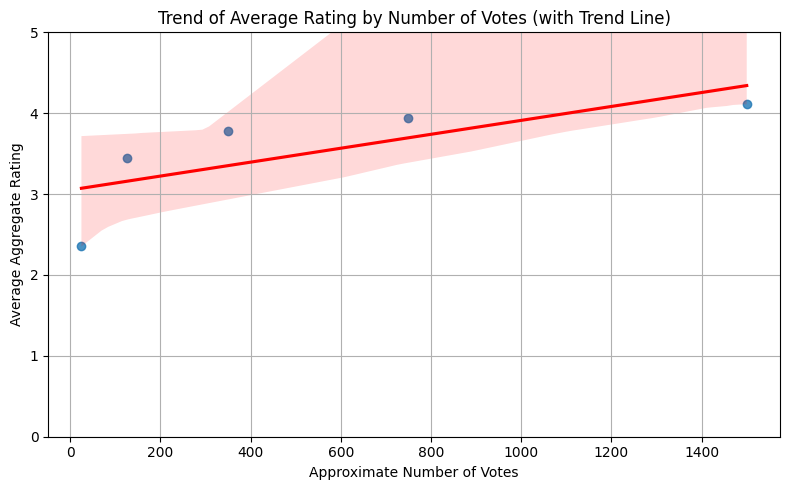

In [ ]:

# Step 1: Group the data by vote ranges
zomato_df['Vote Group'] = pd.cut(
    zomato_df['Votes'],
    bins=[0, 50, 200, 500, 1000, zomato_df['Votes'].max()],
    labels=['0–50', '51–200', '201–500', '501–1000', '1000+']
)

# Step 2: Calculate average rating per vote group
avg_rating_by_votes = zomato_df.groupby('Vote Group')['Aggregate rating'].mean().reset_index()

# Step 3: Assign approximate midpoints for each vote group
vote_midpoints = [25, 125, 350, 750, 1500]  # approximate midpoints
avg_rating_by_votes['Vote Midpoint'] = vote_midpoints

# Step 4: Plot the regression line
plt.figure(figsize=(8, 5))
sns.regplot(
    data=avg_rating_by_votes,
    x='Vote Midpoint',
    y='Aggregate rating',
    marker='o',
    line_kws={'color': 'red'}
)

plt.title('Trend of Average Rating by Number of Votes (with Trend Line)')
plt.xlabel('Approximate Number of Votes')
plt.ylabel('Average Aggregate Rating')
plt.ylim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()


**📌 Decision Support for New Ventures**

Problem:
Where and how should a new restaurant be launched?

Use:

 1. Supports data-driven decisions for food entrepreneurs.

 2. Minimizes risk by analyzing successful patterns.

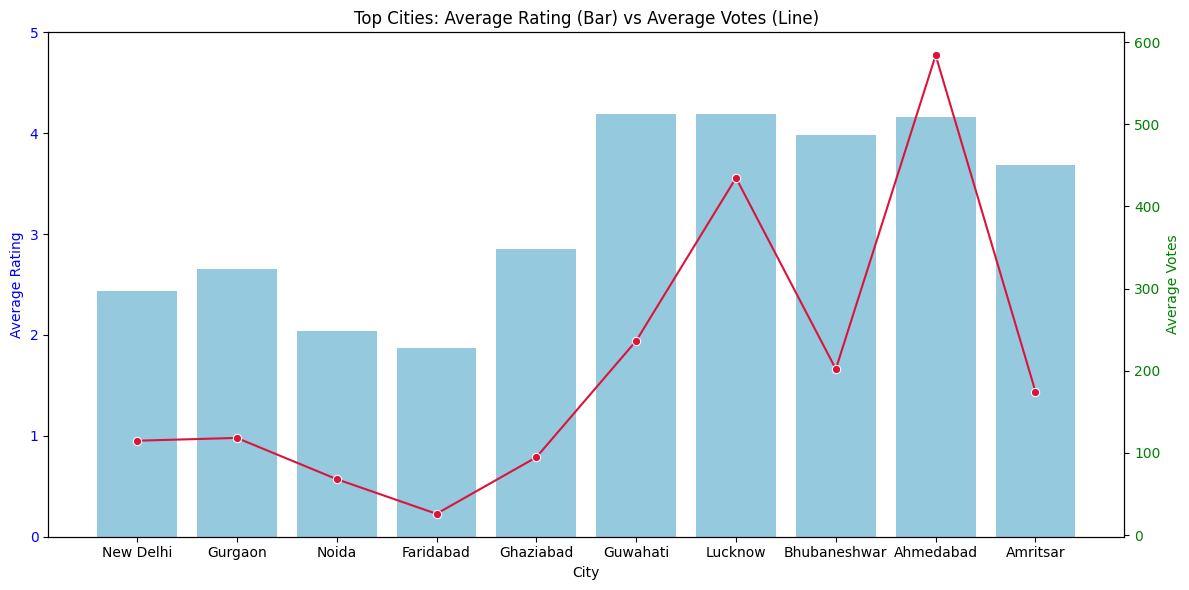

In [ ]:

# Step 1: Group by city and calculate averages
city_engagement = zomato_df.groupby('City').agg({
    'Aggregate rating': 'mean',
    'Votes': 'mean',
    'Restaurant Name': 'count'
}).reset_index()

# Rename columns
city_engagement.columns = ['City', 'Average Rating', 'Average Votes', 'Restaurant Count']

# Step 2: Select top 10 cities by restaurant count
top_cities = city_engagement.sort_values(by='Restaurant Count', ascending=False).head(10)

# Step 3: Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for average rating
sns.barplot(
    data=top_cities,
    x='City',
    y='Average Rating',
    color='skyblue',
    ax=ax1
)
ax1.set_ylabel('Average Rating', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 5)

# Line plot for average votes (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(
    data=top_cities,
    x='City',
    y='Average Votes',
    color='crimson',
    marker='o',
    ax=ax2
)
ax2.set_ylabel('Average Votes', color='Green')
ax2.tick_params(axis='y', labelcolor='Green')

plt.title('Top Cities: Average Rating (Bar) vs Average Votes (Line)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**To Know their Restuarant Name and their details.**

In [ ]:
# Input restaurant name (you can change this value or use input())
restaurant_name = input("Enter the restaurant name: ")
# 🔁 Replace this with any name you want

# Search for matching restaurant(s)
restaurant_info = zomato_df[zomato_df['Restaurant Name'].str.lower() == restaurant_name.lower()]

# Show all columns and details for that restaurant
if not restaurant_info.empty:
    display(restaurant_info)
else:
    print(f"No restaurant found with the name: {restaurant_name}")


Enter the restaurant name: The Chaiwalas


,Restaurant ID,Restaurant Name,City,Address,Zone,Average Cost for two,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisines,Vote Group
250,18433852.0,The Chaiwalas,Faridabad,"Sector 21 A, Asian Hospital, Badhkal Chowk, Ba...",Northern Zone,300.0,1.0,0.0,White,Not rated,0.0,"American, Coffee and Tea",NaN
379,18433879.0,The Chaiwalas,Faridabad,"Asian Institute of Medical Sciences, Near Badh...",Northern Zone,300.0,1.0,0.0,White,Not rated,0.0,"Burger, Bar Food",NaN
8262,18128867.0,The Chaiwalas,Noida,"Shop 1, Ground Floor, Tower B, Okaya Business ...",Northern Zone,300.0,1.0,2.9,Orange,Average,9.0,"North Indian, Mughlai, Chinese, Fast Food",0–50


**To Count Restuarant with their city lower competition**

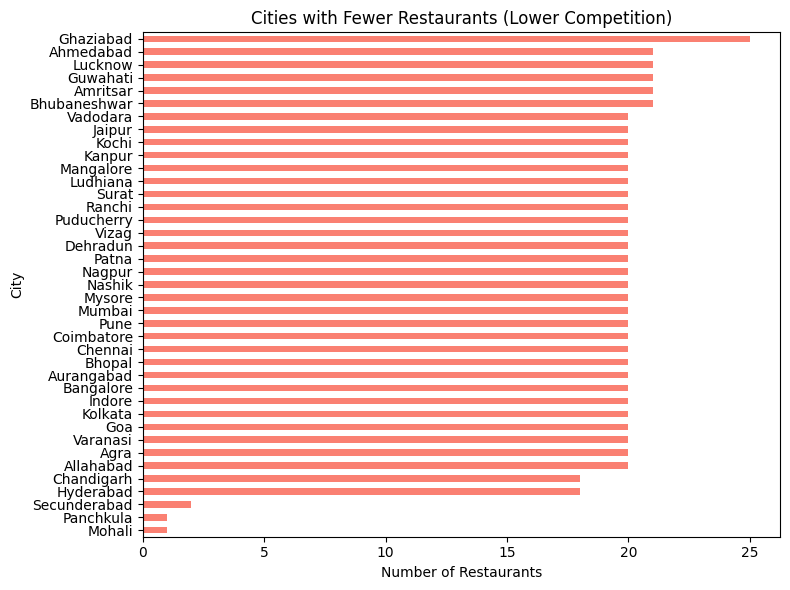

In [ ]:
# Count restaurants per city
city_counts =zomato_df['City'].value_counts()

# Cities with the least restaurants (opportunity zones)
few_restaurants = city_counts[city_counts < 50].sort_values()

few_restaurants.plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Cities with Fewer Restaurants (Lower Competition)")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.tight_layout()
plt.show()


**Top cuisines by their city**

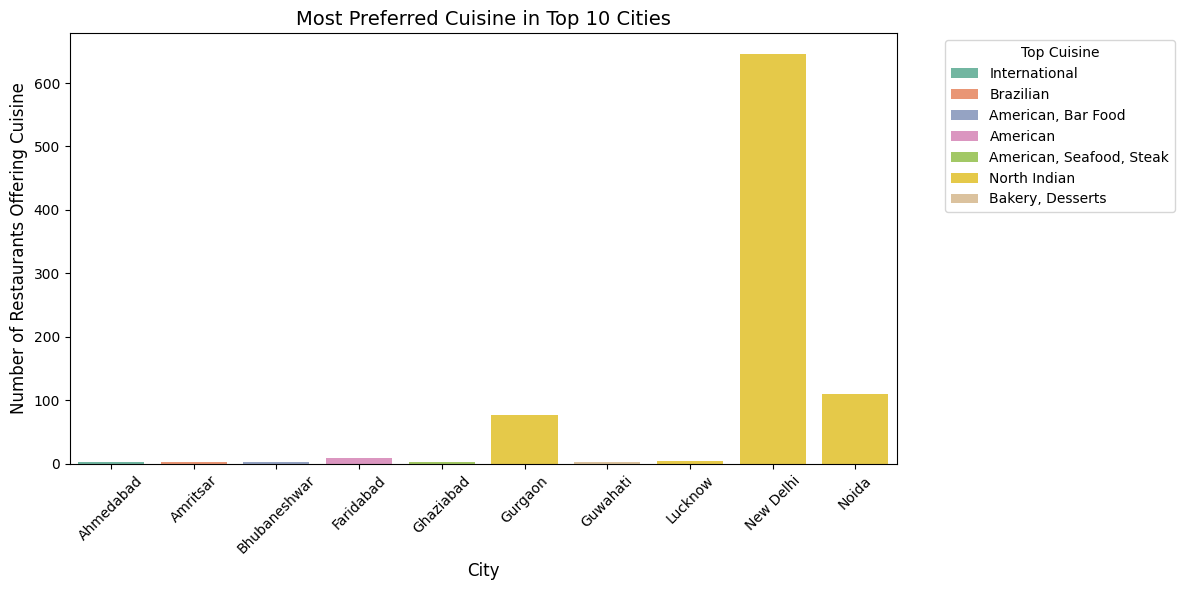

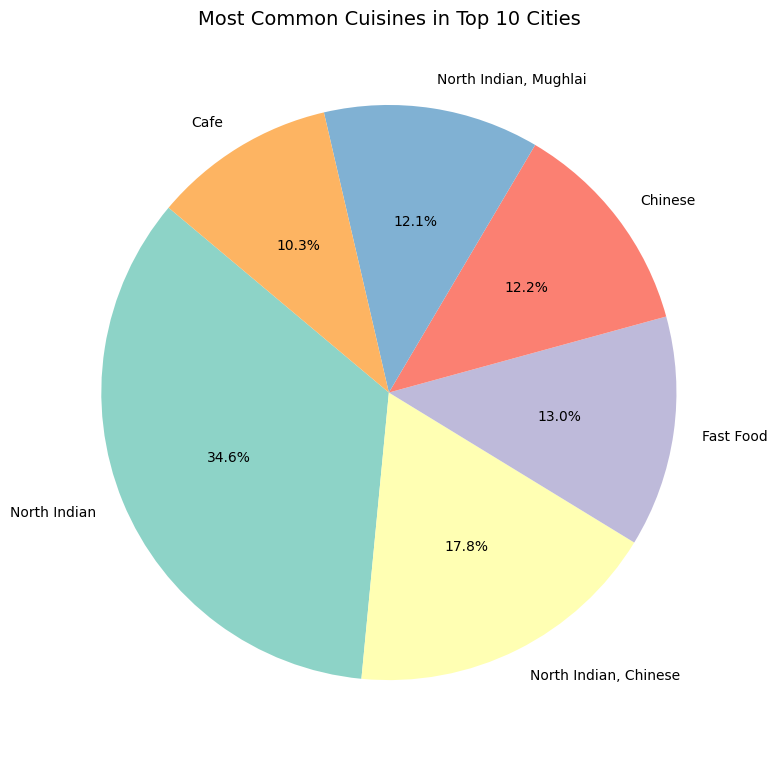

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Zomato data.csv")

# Drop rows with missing cuisines
df_cuisine = df.dropna(subset=['Cuisines'])

# Get top 10 cities with most restaurants
top_cities = df['City'].value_counts().head(10).index.tolist()

# Filter for top cities
df_top_cities = df_cuisine[df_cuisine['City'].isin(top_cities)]

# -------------------------------
# BAR CHART: Top Cuisine in Each Top City
# -------------------------------
top_cuisine_counts = df_top_cities.groupby(['City', 'Cuisines']).size().reset_index(name='Count')
top_city_cuisines = top_cuisine_counts.sort_values(['City', 'Count'], ascending=[True, False]).drop_duplicates('City')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_city_cuisines, x='City', y='Count', hue='Cuisines', dodge=False, palette='Set2')
plt.title('Most Preferred Cuisine in Top 10 Cities', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Restaurants Offering Cuisine', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Top Cuisine', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# PIE CHART: Overall Top Cuisines in Top Cities
# -------------------------------
cuisine_counts = df_top_cities['Cuisines'].value_counts().head(6)

plt.figure(figsize=(8, 8))
plt.pie(cuisine_counts.values, labels=cuisine_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set3'))
plt.title('Most Common Cuisines in Top 10 Cities', fontsize=14)
plt.tight_layout()
plt.show()


1.  People's food choices change from city to city.
Every city has its own favorite types of food based on local taste and culture.

2. American and fast food styles are common favorites.
Many cities have a high number of restaurants serving American, burgers, or pizza.

3. Offering the right cuisine in the right location is important.
Matching your menu to local preferences can bring more customers.

4. Some cuisines are popular everywhere.
These include American, North Indian, and Italian foods.

5. To open a successful restaurant, study which cuisines are already doing well in that city.
Then focus on quality and customer satisfaction to stand out.